### [XGBoost Feature Importance](https://medium.com/data-and-beyond/e509c0df17b9)

> *Three different methods, one dataset, and honest surprises about which features actually matter*

In [1]:
import sys

import warnings
warnings.filterwarnings("ignore")

from IPython.display import display

IN_COLAB = 'google.colab' in sys.modules

import numpy as np
import pandas as pd

import shap
import xgboost as xgb

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['figure.dpi'] = 250
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

%autosave 10

Autosaving every 10 seconds


In [2]:
X, y = make_classification(
  n_samples=3_000,
  n_features=15,
  n_informative=5,
  n_redundant=3,   # correlated with informative
  n_repeated=2,    # duplicates of informative
  random_state=42,
)

feature_names = (
  [f"informative_{i}" for i in range(5)]
  + [f"redundant_{i}" for i in range(3)]
  + [f"repeated_{i}" for i in range(2)]
  + [f"useless_{i}" for i in range(5)]
)

X = pd.DataFrame(X, columns=feature_names)

display(X.head(10))

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.25, stratify=y, random_state=42
)

,informative_0,informative_1,informative_2,informative_3,informative_4,redundant_0,redundant_1,redundant_2,repeated_0,repeated_1,useless_0,useless_1,useless_2,useless_3,useless_4
0,-0.8190,0.1310,-4.5621,5.6343,5.5180,3.1757,0.7035,0.1310,3.1757,2.0454,1.5286,0.0179,-1.1488,0.9944,3.3486
1,0.9079,-3.0446,1.7890,2.1664,3.7793,0.4048,0.0174,-3.0446,0.4048,0.7386,1.5767,-0.8715,-0.0936,0.4856,1.0034
2,0.5335,-0.8779,-2.1218,-1.4938,-1.1225,-0.2936,0.6764,-0.8779,-0.2936,-1.9100,-3.1704,-0.2407,1.1425,0.8966,2.5938
3,-1.0783,0.5618,0.6515,-0.3362,0.6377,-0.6896,1.5100,0.5618,-0.6896,0.2882,2.2721,0.5920,-0.7255,1.2577,-0.8007
4,0.1398,1.1743,-1.3172,-0.7313,-1.2558,-1.4254,1.9697,1.1743,-1.4254,0.1742,-0.2195,0.0395,0.0436,-1.0385,1.4664
5,0.8840,-0.9625,-1.1550,4.6161,4.3935,1.2073,1.6093,-0.9625,1.2073,2.5272,1.9603,-0.3182,0.0166,-1.6855,2.4943
6,1.0788,-0.6393,-0.7298,1.2941,1.4829,1.3062,0.4231,-0.6393,1.3062,0.0456,-0.2052,1.1094,-2.0909,-0.2516,0.4616
7,1.1690,-0.6916,-1.6237,0.4126,-0.3114,0.2344,-0.0533,-0.6916,0.2344,-0.3400,-2.4129,-0.0559,0.0198,0.4275,2.2968
8,-0.4152,0.2022,-2.5388,4.0945,1.2651,3.1318,-0.0840,0.2022,3.1318,1.6293,-2.2199,-2.1972,-1.0776,1.2634,1.3139
9,0.4346,2.2145,-0.7917,0.3032,-0.8808,-1.7884,-0.7714,2.2145,-1.7884,1.7001,1.6329,1.4593,-0.2233,0.3210,0.8400


In [3]:
model = xgb.XGBClassifier(
  n_estimators=200, max_depth=5,
  learning_rate=0.1, subsample=0.8,
  colsample_bytree=0.8, random_state=42,
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

#### **Native XGBoost Feature Importance**

In [4]:
# Get any of the three sub-types
scores = model.get_booster().get_score(importance_type="gain")

# Or use the sklearn-compatible attribute (defaults to "weight")
importances = pd.Series(
  model.feature_importances_,
  index=feature_names
).sort_values(ascending=False)

display(importances)

,0
informative_1,0.1114
useless_0,0.1058
redundant_0,0.1048
informative_3,0.1007
useless_4,0.0956
repeated_1,0.0847
informative_4,0.0822
redundant_2,0.0782
informative_2,0.0691
repeated_0,0.0395


#### **Permutation Importance**

In [5]:
result = permutation_importance(
  model, X_test, y_test,
  n_repeats=20,         # shuffle each feature 20 times, take average
  scoring="roc_auc",
  random_state=42,
  n_jobs=-1,
)
perm_df = pd.DataFrame({
  "mean_drop": result.importances_mean,
  "std":       result.importances_std,
}, index=feature_names).sort_values("mean_drop", ascending=False)

display(perm_df)

,mean_drop,std
useless_0,0.1363,0.0092
repeated_1,0.0658,0.0066
useless_4,0.0447,0.0054
informative_1,0.0349,0.0039
informative_3,0.0286,0.0034
informative_4,0.0278,0.0034
informative_2,0.0203,0.0032
redundant_0,0.0167,0.0020
redundant_2,0.0013,0.0008
informative_0,0.0008,0.0007


#### **SHAP values**

In [6]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)   # shape: (n_samples, n_features)

# Global importance = mean absolute SHAP across test set
shap_importance = pd.Series(
  np.abs(shap_values).mean(axis=0),
  index=feature_names,
).sort_values(ascending=False)

display(shap_importance)

,0
useless_0,1.1431
useless_4,0.7055
informative_1,0.5852
repeated_1,0.5762
informative_4,0.5095
informative_2,0.4101
informative_3,0.4029
redundant_0,0.3665
useless_1,0.1619
redundant_1,0.1619


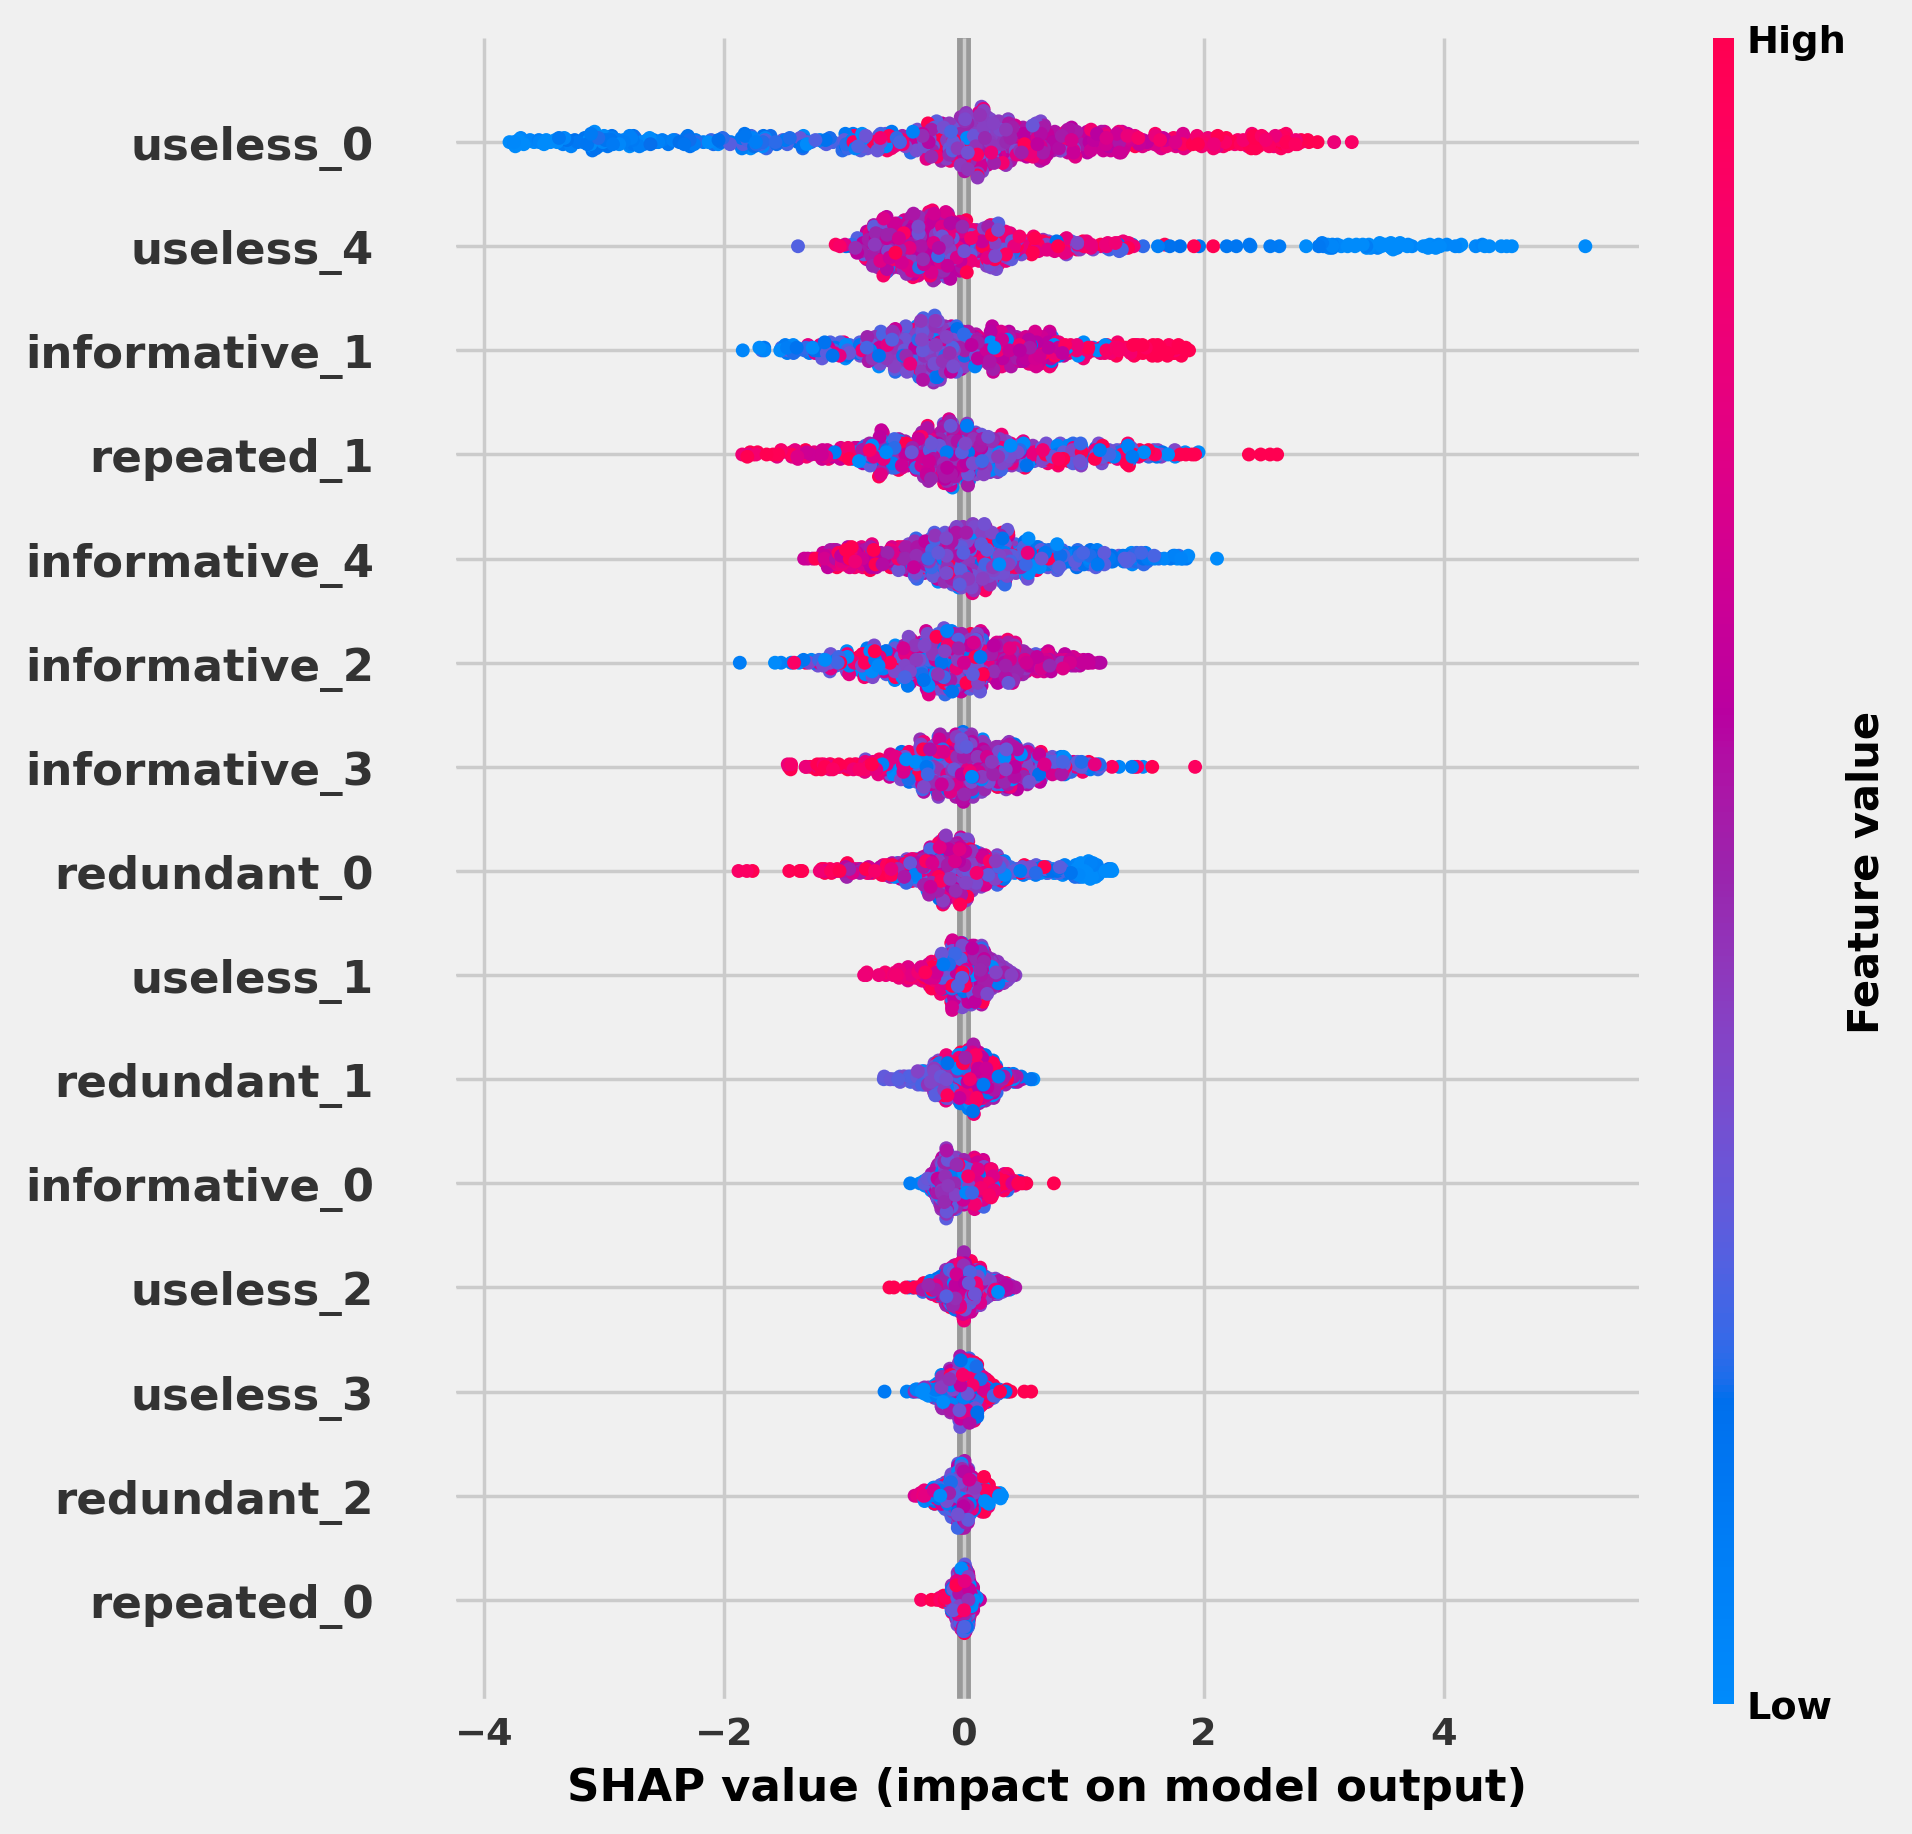

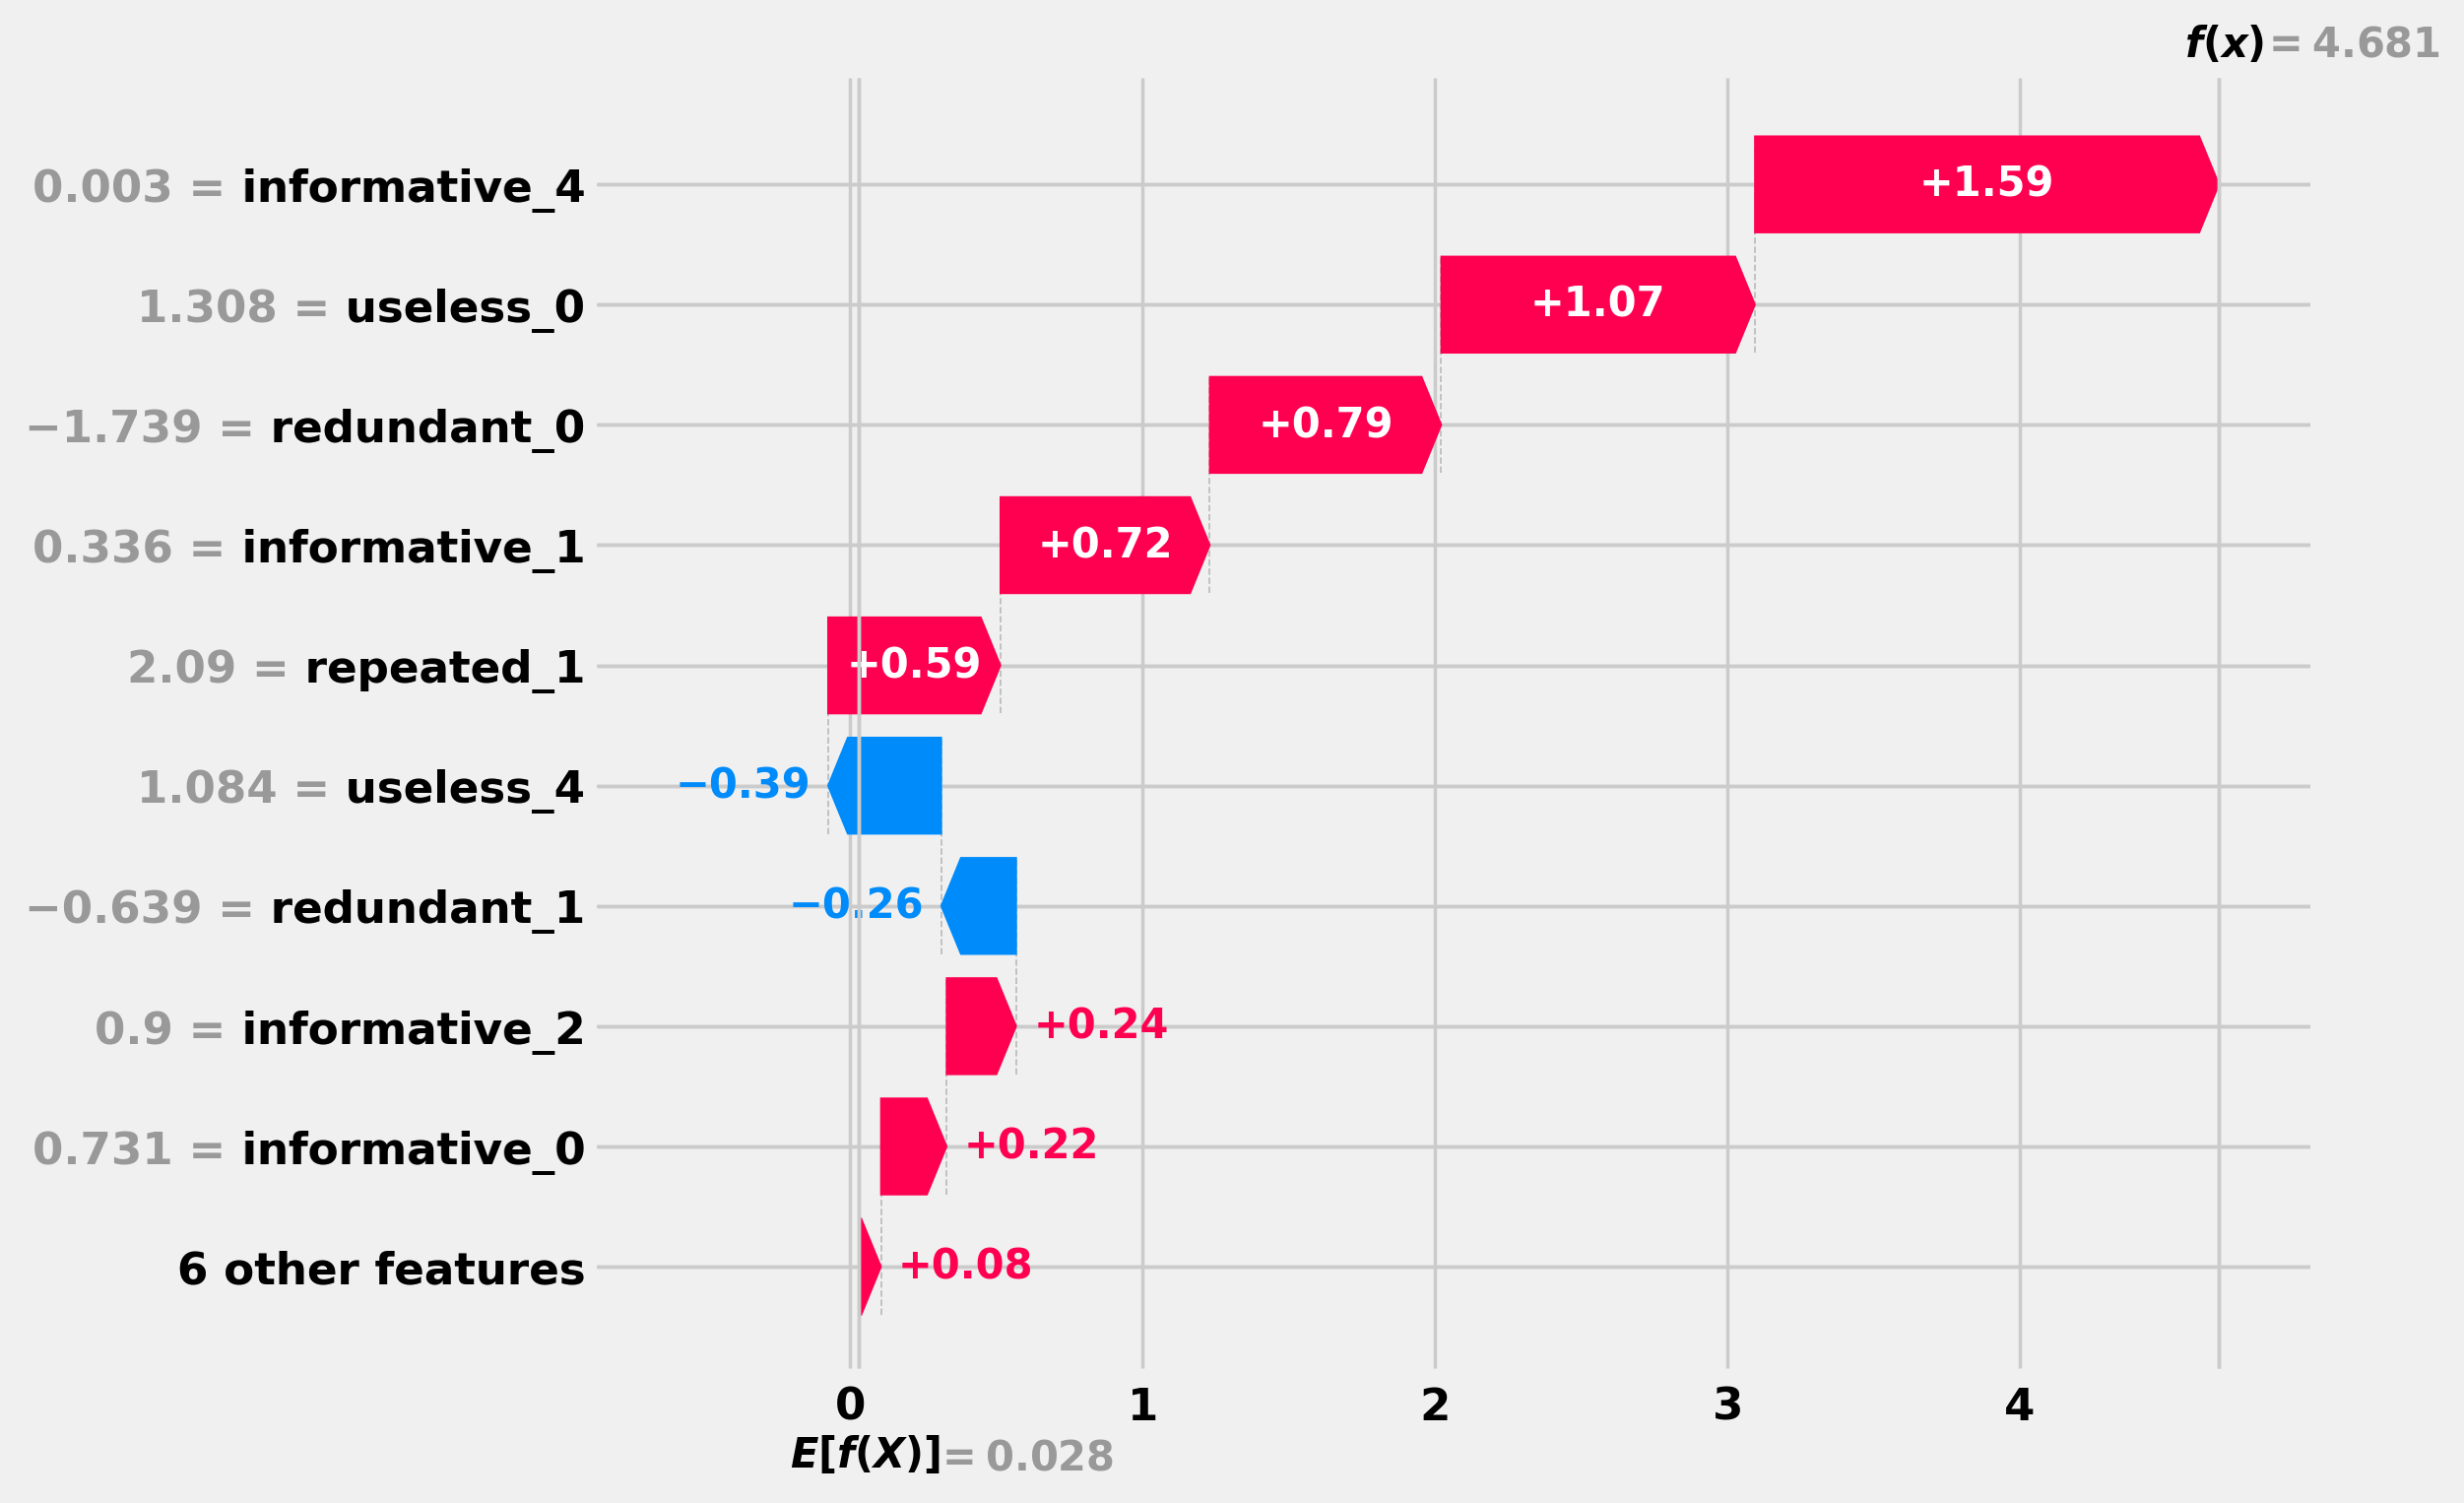

In [7]:
# Beeswarm plot: each dot is one test sample
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

# Waterfall for one prediction
shap.waterfall_plot(
  shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0],
    feature_names=feature_names,
  )
)